# E1 Experiment: `dev_e1_javier`

Visualize train/eval loss and token accuracy from W&B runs tagged `dev_e1_javier`. And output a table that we could put in a paper appendix.

In [56]:
import wandb_buddy as wb
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# ── Run selection (edit here) ──────────────────────────────────────────
RUN_TO_DISPLAY_NAME = {
    'e1_llm': 'LLM (Baseline)',
    'e1_llm_noedges': 'LLM (No Edges)',
    'e1_rpearl_noedges': 'RPEARL-LLM (No Edges)',
    'e1_rpearl_plus_edges': 'RPEARL-LLM (+ Edges)',
    # outtakes
    #'e1_rpearl_llm(Broken)': 'RPEARL-LLM (Broken)',
    #'dev_e1_javier_llm': 'LLM (old)',
    #'e1_rpearl_llm_fix_inject': 'RPEARL-LLM (fix_inject)',
    #'e1_rpearl_llm_w_edges_tuning': 'RPEARL-LLM (Tuning)',
}
BASELINE_NAME = 'LLM (Baseline)'

In [57]:
# use only "important" runs
df = wb.load_runs("alelab", "GREP-PRISM", tags=["dev_e1_javier"], state="all")
df = df[df.tags.apply(lambda x: "important" in x)]

print(f"Loaded {len(df)} runs")
#df.columns.tolist()

Loaded 5 runs


In [58]:
df

,name,id,state,created_at,heartbeat_at,tags,sweep_id,bf16,fp16,fsdp,seed,tf32,debug,dtype,optim,do_eval,packing,project,use_cpu,do_train,head_dim,id2label,label2id,mlp_bias,run_name,data_seed,deepspeed,eos_token,hub_token,log_level,loss_type,max_steps,pad_token,report_to,use_cache,adam_beta1,adam_beta2,do_predict,eval_delay,eval_steps,hidden_act,local_rank,max_length,model_type,optim_args,output_dir,save_steps,vocab_size,ddp_backend,ddp_timeout,fsdp_config,hidden_size,label_names,logging_dir,peft_config,push_to_hub,return_dict,adam_epsilon,bos_token_id,disable_tqdm,eos_token_id,eval_packing,hub_model_id,hub_revision,hub_strategy,pad_token_id,padding_free,problem_type,rms_norm_eps,warmup_ratio,warmup_steps,weight_decay,_name_or_path,architectures,eval_on_start,eval_strategy,learning_rate,logging_steps,max_grad_norm,save_strategy,torch_compile,attention_bias,bf16_full_eval,dataset_kwargs,fp16_full_eval,pretraining_tp,group_by_length,hub_always_push,rope_parameters,save_only_model,shuffle_dataset,dataset_num_proc,full_determinism,hub_private_repo,ignore_data_skip,log_on_each_node,logging_strategy,num_train_epochs,packing_strategy,save_total_limit,trackio_space_id,use_liger_kernel,attention_dropout,ddp_bucket_cap_mb,greater_is_better,initializer_range,intermediate_size,log_level_replica,lr_scheduler_type,model_init_kwargs,num_hidden_layers,output_attentions,save_on_each_node,accelerator_config,batch_eval_metrics,chat_template_path,dataset_text_field,is_encoder_decoder,length_column_name,logging_first_step,pad_to_multiple_of,parallelism_config,torch_compile_mode,assistant_only_loss,include_for_metrics,liger_kernel_config,lr_scheduler_kwargs,neftune_noise_alpha,num_attention_heads,num_key_value_heads,skip_memory_metrics,tie_word_embeddings,auto_find_batch_size,completion_only_loss,dataloader_drop_last,model/num_parameters,optim_target_modules,output_hidden_states,prediction_loss_only,transformers_version,activation_offloading,dataloader_pin_memory,ddp_broadcast_buffers,enable_jit_checkpoint,metric_for_best_model,remove_unused_columns,torch_compile_backend,dataloader_num_workers,eval_do_concat_batches,eval_use_gather_object,gradient_checkpointing,label_smoothing_factor,load_best_model_at_end,logging_nan_inf_filter,resume_from_checkpoint,chunk_size_feed_forward,eval_accumulation_steps,max_position_embeddings,torch_empty_cache_steps,dataloader_prefetch_factor,ddp_find_unused_parameters,per_device_eval_batch_size,gradient_accumulation_steps,per_device_train_batch_size,average_tokens_across_devices,dataloader_persistent_workers,gradient_checkpointing_kwargs,include_num_input_tokens_seen,restore_callback_states_from_checkpoint,_runtime,_step,_timestamp,_wandb,eval/entropy,eval/loss,eval/mean_token_accuracy,eval/num_tokens,eval/runtime,eval/samples_per_second,eval/steps_per_second,total_flos,train/entropy,train/epoch,train/global_step,train/grad_norm,train/learning_rate,train/loss,train/mean_token_accuracy,train/num_tokens,train_loss,train_runtime,train_samples_per_second,train_steps_per_second,debug/embedding_norm,debug/grad_norm_gnn,debug/grad_norm_lora,debug/grad_norm_pe_proj,debug/lr,debug/num_injections,debug/pe_has_nan,debug/pe_output_norm
3,e1_rpearl_llm(Broken),d09h2hs2,finished,2026-02-12T16:58:41Z,2026-02-12T17:21:41Z,"[baseline, dev_e1_javier, important]",None,True,False,[],3407,None,[],bfloat16,adamw_torch_fused,True,False,huggingface,False,False,128,"{'0': 'LABEL_0', '1': 'LABEL_1'}","{'LABEL_0': 0, 'LABEL_1': 1}",False,dev_e1_javier_rpearl_llm,None,None,<EOS_TOKEN>,<HUB_TOKEN>,passive,nll,-1,<PAD_TOKEN>,[wandb],False,0.9,0.999,False,0,100,silu,-1,2048,llama,None,outputs/dev_e1_javier_rpearl_llm_r16,500,128256,None,1800,"{'xla': False, 'xla_fsdp_v2': False, 'min_num_...",3072,None,None,"{'default': {'r': 16, 'bias': 'none', 'revisio...",False,True,1.000000e-08,128000,False,128009,None,None,None,every_save,128009,False,None,0.00001,None,5,0.05,meta-llama/Llama-3.2-3B-Instruct,[LlamaForCausalLM],False,steps,0.0002,15,1,steps,Fal

## Inspect columns
Find the relevant metric columns for loss and token accuracy.

In [59]:
# Show all columns that look like metrics
metric_cols = [c for c in df.columns if any(k in c.lower() for k in ["loss", "accuracy", "acc", "eval", "train"])]
print("Metric-related columns:")
for c in sorted(metric_cols):
    print(f"  {c}")

Metric-related columns:
  accelerator_config
  assistant_only_loss
  batch_eval_metrics
  bf16_full_eval
  completion_only_loss
  do_eval
  do_train
  eval/entropy
  eval/loss
  eval/mean_token_accuracy
  eval/num_tokens
  eval/runtime
  eval/samples_per_second
  eval/steps_per_second
  eval_accumulation_steps
  eval_delay
  eval_do_concat_batches
  eval_on_start
  eval_packing
  eval_steps
  eval_strategy
  eval_use_gather_object
  fp16_full_eval
  gradient_accumulation_steps
  loss_type
  num_train_epochs
  per_device_eval_batch_size
  per_device_train_batch_size
  prediction_loss_only
  pretraining_tp
  train/entropy
  train/epoch
  train/global_step
  train/grad_norm
  train/learning_rate
  train/loss
  train/mean_token_accuracy
  train/num_tokens
  train_loss
  train_runtime
  train_samples_per_second
  train_steps_per_second


In [60]:
# Identify key columns — adjust these if the column names differ
# Common HF Trainer patterns: train/loss, eval/loss, eval/mean_token_accuracy
ID_COL = "name"  # run name

# Auto-detect columns
def find_col(keywords, cols):
    for c in cols:
        cl = c.lower()
        if all(k in cl for k in keywords):
            return c
    return None

TRAIN_LOSS = find_col(["train", "loss"], metric_cols)
EVAL_LOSS = find_col(["eval", "loss"], metric_cols)
EVAL_TOKEN_ACC = find_col(["eval", "token", "acc"], metric_cols)

# Try alternate name for train loss
if TRAIN_LOSS is None:
    TRAIN_LOSS = find_col(["train_loss"], metric_cols) or find_col(["loss"], metric_cols)

print(f"Train loss col:      {TRAIN_LOSS}")
print(f"Eval loss col:       {EVAL_LOSS}")
print(f"Eval token acc col:  {EVAL_TOKEN_ACC}")

Train loss col:      train/loss
Eval loss col:       eval/loss
Eval token acc col:  eval/mean_token_accuracy


## Summary Table

In [61]:
summary_cols = [c for c in [ID_COL, "state", TRAIN_LOSS, EVAL_LOSS, EVAL_TOKEN_ACC] if c is not None]
df_summary = df[summary_cols].copy()
df_summary

,name,state,train/loss,eval/loss,eval/mean_token_accuracy
3,e1_rpearl_llm(Broken),finished,0.107138,0.136460,0.957572
4,e1_llm,finished,0.051690,0.078582,0.975186
7,e1_llm_noedges,finished,0.094133,0.123835,0.961173
18,e1_rpearl_plus_edges,finished,0.071637,0.105656,0.968671
19,e1_rpearl_noedges,finished,0.069623,0.101378,0.969133


## Plots

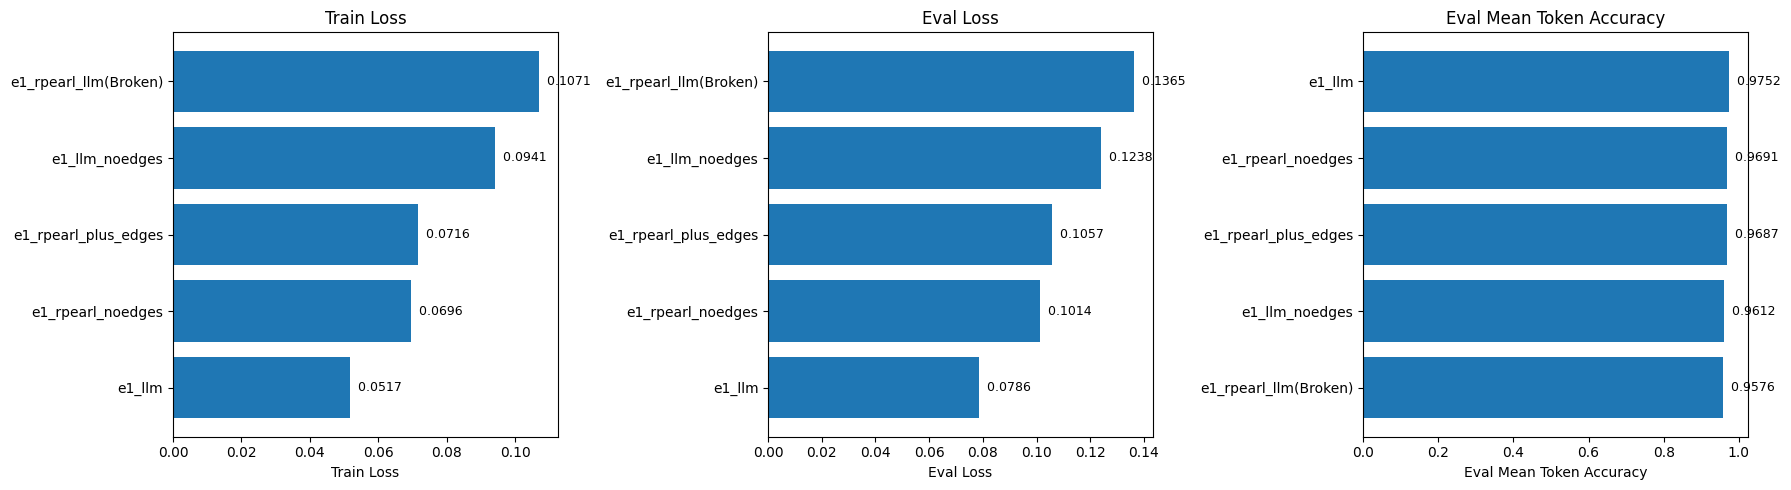

In [62]:
plot_metrics = [(TRAIN_LOSS, "Train Loss"), (EVAL_LOSS, "Eval Loss"), (EVAL_TOKEN_ACC, "Eval Mean Token Accuracy")]
plot_metrics = [(col, label) for col, label in plot_metrics if col is not None]

fig, axes = plt.subplots(1, len(plot_metrics), figsize=(6 * len(plot_metrics), 5))
if len(plot_metrics) == 1:
    axes = [axes]

for ax, (col, label) in zip(axes, plot_metrics):
    data = df[[ID_COL, col]].dropna(subset=[col]).sort_values(col)
    bars = ax.barh(data[ID_COL], data[col])
    ax.set_xlabel(label)
    ax.set_title(label)
    # Annotate bars
    for bar, val in zip(bars, data[col]):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
                f"  {val:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## Per-run history plots (loss curves over training steps)

In [63]:
import wandb

api = wandb.Api()
runs = api.runs("alelab/GREP-PRISM", filters={"tags": "dev_e1_javier"})

histories = {}
for run in runs:
    hist = run.history(pandas=True)
    histories[run.name] = hist
    print(f"{run.name}: {len(hist)} steps")

dev_e1_javier_rpearl_llm: 14 steps
dev_e1_javier_rpearl_llm: 14 steps
dev_e1_javier_llm: 14 steps
e1_rpearl_llm(Broken): 136 steps
e1_llm: 136 steps
dev_e1_javier_rpearl_llm: 30 steps
dev_e1_javier_rpearl_llm: 136 steps
e1_llm_noedges: 136 steps
dev_e1_javier_rpearl_llm: 136 steps
e1_rpearl_llm_fix_inject: 136 steps
dev_e1_javier_llm: 136 steps
e1_rpearl_llm_no_edges: 136 steps
e1_rpearl_plus_edges: 136 steps
dev_e1_javier_rpearl_llm: 0 steps
dev_e1_javier_rpearl_llm: 60 steps
dev_e1_javier_rpearl_llm: 136 steps
dev_e1_javier_rpearl_llm: 136 steps
e1_rpearl_llm_w_edges_tuning: 136 steps
e1_rpearl_plus_edges: 137 steps
e1_rpearl_noedges: 137 steps


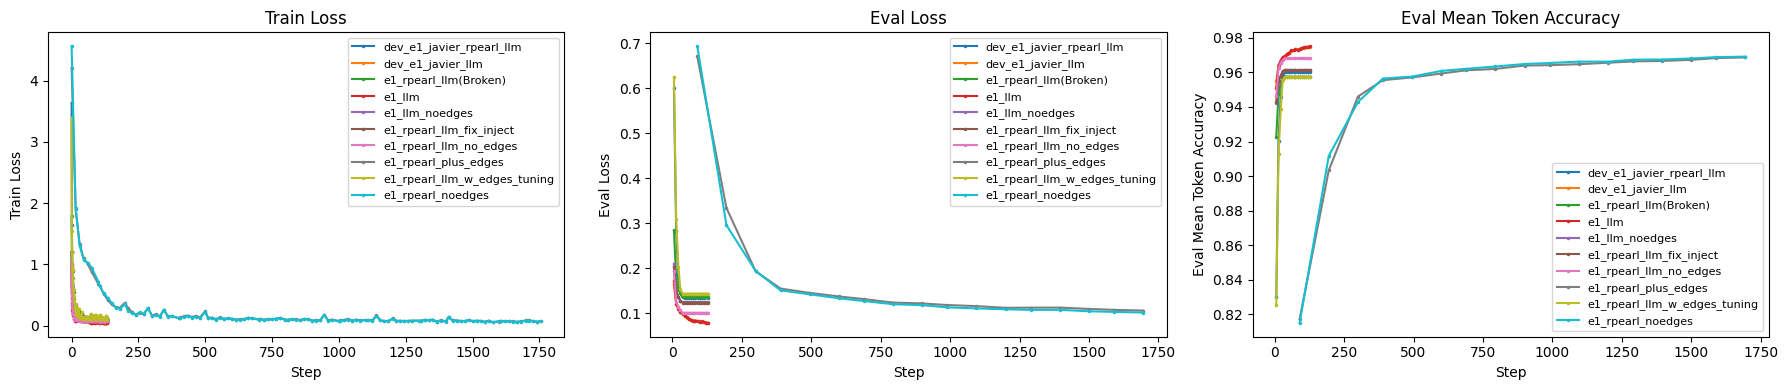

In [64]:
# Detect history column names from first run
sample_hist = next(iter(histories.values()))
hist_cols = sample_hist.columns.tolist()
h_train_loss = find_col(["train", "loss"], hist_cols) or find_col(["loss"], hist_cols)
h_eval_loss = find_col(["eval", "loss"], hist_cols)
h_eval_acc = find_col(["eval", "token", "acc"], hist_cols)

history_metrics = [
    (h_train_loss, "Train Loss"),
    (h_eval_loss, "Eval Loss"),
    (h_eval_acc, "Eval Mean Token Accuracy"),
]
history_metrics = [(c, l) for c, l in history_metrics if c is not None]

fig, axes = plt.subplots(1, len(history_metrics), figsize=(6 * len(history_metrics), 4))
if len(history_metrics) == 1:
    axes = [axes]

for ax, (col, label) in zip(axes, history_metrics):
    for run_name, hist in histories.items():
        series = hist[["_step", col]].dropna(subset=[col])
        ax.plot(series["_step"], series[col], label=run_name, marker=".", markersize=3)
    ax.set_xlabel("Step")
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## LaTeX Table — Eval Token Error Rate

In [65]:
df.name.unique().tolist()

['e1_rpearl_llm(Broken)',
 'e1_llm',
 'e1_llm_noedges',
 'e1_rpearl_plus_edges',
 'e1_rpearl_noedges']

In [66]:
df_to_report = df[df.name.isin(RUN_TO_DISPLAY_NAME.keys())].copy()
df_to_report["name"] = df_to_report["name"].map(RUN_TO_DISPLAY_NAME)

In [67]:
latex_df = df_to_report[[ID_COL, EVAL_TOKEN_ACC]].dropna(subset=[EVAL_TOKEN_ACC]).copy()

# Compute token error rate = (1 - accuracy) * 100
latex_df["Eval Token Error Rate"] = ((1 - latex_df[EVAL_TOKEN_ACC]) * 100).round(2)
latex_df = latex_df.drop(columns=[EVAL_TOKEN_ACC])
latex_df = latex_df.rename(columns={ID_COL: "Run"})
latex_df = latex_df.sort_values("Eval Token Error Rate", ascending=True).reset_index(drop=True)

# Compute diff and relative error vs baseline
baseline_err = latex_df[latex_df["Run"] == BASELINE_NAME]["Eval Token Error Rate"].iloc[0]
latex_df["Diff vs Baseline"] = (latex_df["Eval Token Error Rate"] - baseline_err).round(2)
latex_df["Relative Error vs Baseline"] = (((latex_df["Eval Token Error Rate"] - baseline_err) / baseline_err) * 100).round(1)

# Format with % and + signs
latex_df["Eval Token Error Rate"] = latex_df["Eval Token Error Rate"].apply(lambda x: f"{x:.2f}%")
latex_df["Diff vs Baseline"] = latex_df["Diff vs Baseline"].apply(lambda x: f"+{x:.2f}%" if x >= 0 else f"{x:.2f}%")
latex_df["Relative Error vs Baseline"] = latex_df["Relative Error vs Baseline"].apply(lambda x: f"+{x:.1f}%" if x >= 0 else f"{x:.1f}%")

# Display as pandas
display(latex_df)

# Print copy-pasteable LaTeX
print("\n% Copy-paste the LaTeX below:\n")
latex_str = latex_df.to_latex(
    index=False,
    caption="Eval Token Error Rate for E1",
    label="tab:e1_token_err",
)
print(latex_str)

,Run,Eval Token Error Rate,Diff vs Baseline,Relative Error vs Baseline
0,LLM (Baseline),2.48%,+0.00%,+0.0%
1,RPEARL-LLM (No Edges),3.09%,+0.61%,+24.6%
2,RPEARL-LLM (+ Edges),3.13%,+0.65%,+26.2%
3,LLM (No Edges),3.88%,+1.40%,+56.5%



% Copy-paste the LaTeX below:

\begin{table}
\caption{Eval Token Error Rate for E1}
\label{tab:e1_token_err}
\begin{tabular}{llll}
\toprule
Run & Eval Token Error Rate & Diff vs Baseline & Relative Error vs Baseline \\
\midrule
LLM (Baseline) & 2.48% & +0.00% & +0.0% \\
RPEARL-LLM (No Edges) & 3.09% & +0.61% & +24.6% \\
RPEARL-LLM (+ Edges) & 3.13% & +0.65% & +26.2% \\
LLM (No Edges) & 3.88% & +1.40% & +56.5% \\
\bottomrule
\end{tabular}
\end{table}

